In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [4]:
import os

os.getcwd()

'c:\\Users\\k\\Problem-Solving\\Topics\\Statistics\\3_Regression\\Linear_regression\\Ordinary_least_squares'

In [5]:
os.chdir('../')

In [6]:
os.getcwd()

'c:\\Users\\k\\Problem-Solving\\Topics\\Statistics\\3_Regression\\Linear_regression'

In [7]:
df = pd.read_csv("data.csv")

In [8]:
df.head()

,area_m2,rooms,bedrooms,bathrooms,floor,total_floors,building_age_years,distance_city_center_km,distance_public_transport_km,school_rating,crime_index,parks_within_1km,parking_spaces,renovation_score,energy_efficiency_score,noise_level,neighborhood_income_index,has_elevator,is_new_building,apartment_price_usd
0,64.6,3,2,1,9,25,11.7,3.65,1.18,8.1,29.6,0,1,8.5,8.7,43.2,57.4,1,0,402033.11
1,136.7,6,5,2,3,24,26.5,4.13,0.46,8.7,8.2,3,1,7.5,4.1,44.8,74.5,1,0,716709.88
2,99.5,4,3,1,10,29,8.4,5.69,0.71,6.9,30.2,4,1,7.5,8.6,40.0,73.8,0,0,569233.62
3,86.2,4,3,2,25,30,23.8,13.50,0.44,7.1,40.3,0,1,7.6,6.7,41.2,42.7,1,0,388190.73
4,73.7,2,1,2,1,5,63.1,6.55,2.18,6.9,45.6,1,0,4.6,7.0,46.8,65.4,0,0,296126.18


In [9]:
X = df.drop(columns="apartment_price_usd")
y = df["apartment_price_usd"]

n_samples = X.shape[0]

np.random.seed(42)
indices = np.random.permutation(n_samples)

X_shuffled = X.iloc[indices]
y_shuffled = y.iloc[indices]

# Training set
X_train = X_shuffled.iloc[:4000]
y_train = y_shuffled.iloc[:4000]

# Test set
X_test = X_shuffled.iloc[4000:]
y_test = y_shuffled.iloc[4000:]


# OLS (Ordinary Least Squares)

Converting dataset to numpy arrays

In [10]:
X_matrix = X_train.to_numpy()
y_vector = y_train.to_numpy()

print("Original X shape:", X_matrix.shape)
print("y shape:", y_vector.shape)

Original X shape: (4000, 19)
y shape: (4000,)


In [11]:
ones = np.ones((X_matrix.shape[0], 1))
X_with_intercept = np.hstack((ones, X_matrix))

print(ones.shape)
print(X_with_intercept.shape)

(4000, 1)
(4000, 20)


calculating model parameters (intercept and coefficients)

In [12]:
beta_hat = (
    np.linalg.pinv(
        X_with_intercept.T @ X_with_intercept
    )
    @ X_with_intercept.T 
    @ y_vector
)

intercept = beta_hat[0]
coefficients = beta_hat[1:]
print(f"Intercept: {intercept}")
print(f"Coefficients: {coefficients}")

Intercept: 38013.12022127453
Coefficients: [ 2831.81502057  1699.50470259  8563.9322509  14508.32036336
   893.42281732   254.23566384 -1564.07068125 -6228.04166412
 -8733.58343344  7154.04867708  -926.55845445  4219.58500512
 12304.13366177  4901.82984624  3487.02419751  -896.09482242
  2090.28201897 18020.89702635 21397.83643407]


making predictions

In [13]:
y_train_pred = X_with_intercept @ beta_hat
y_train_pred.shape

(4000,)

In [14]:
y_train_pred[:5]

array([399032.93588223, 384595.62466732, 436122.47302248, 372354.39284711,
       592862.14597133])

Comparing actual values, predicted values and residuals

In [15]:
residuals = y_train - y_train_pred
train_actual_vs_predicted = pd.DataFrame({
    "Actual Values":y_train,
    "Predicted Values":np.round(y_train_pred, 2),
    "Residuals":np.round(residuals, 2)
})
train_actual_vs_predicted.head()

,Actual Values,Predicted Values,Residuals
1501,441317.51,399032.94,42284.57
2586,390986.39,384595.62,6390.77
2653,441213.59,436122.47,5091.12
1055,346111.07,372354.39,-26243.32
705,552155.41,592862.15,-40706.74


SSE (Sum of Squared Errors)

In [16]:
sse = np.sum(residuals **2 )
print(f"SSE(Sum of squared errors): {sse}")

SSE(Sum of squared errors): 1882050257978.62


Model Parameters

In [17]:
parameters = ['intercept'] + list(X_train.columns)
parameters = pd.Series(
    beta_hat,
    index=parameters
)
parameters.sort_values(ascending=False)

intercept                       38013.120221
is_new_building                 21397.836434
has_elevator                    18020.897026
bathrooms                       14508.320363
parking_spaces                  12304.133662
bedrooms                         8563.932251
school_rating                    7154.048677
renovation_score                 4901.829846
parks_within_1km                 4219.585005
energy_efficiency_score          3487.024198
area_m2                          2831.815021
neighborhood_income_index        2090.282019
rooms                            1699.504703
floor                             893.422817
total_floors                      254.235664
noise_level                      -896.094822
crime_index                      -926.558454
building_age_years              -1564.070681
distance_city_center_km         -6228.041664
distance_public_transport_km    -8733.583433
dtype: float64

# Key Assumptions of OLS

## Linearity


In [18]:
X_train.columns

Index(['area_m2', 'rooms', 'bedrooms', 'bathrooms', 'floor', 'total_floors',
       'building_age_years', 'distance_city_center_km',
       'distance_public_transport_km', 'school_rating', 'crime_index',
       'parks_within_1km', 'parking_spaces', 'renovation_score',
       'energy_efficiency_score', 'noise_level', 'neighborhood_income_index',
       'has_elevator', 'is_new_building'],
      dtype='str')

### **area_m2** feature vs (**apartment_price_usd**) target linearity

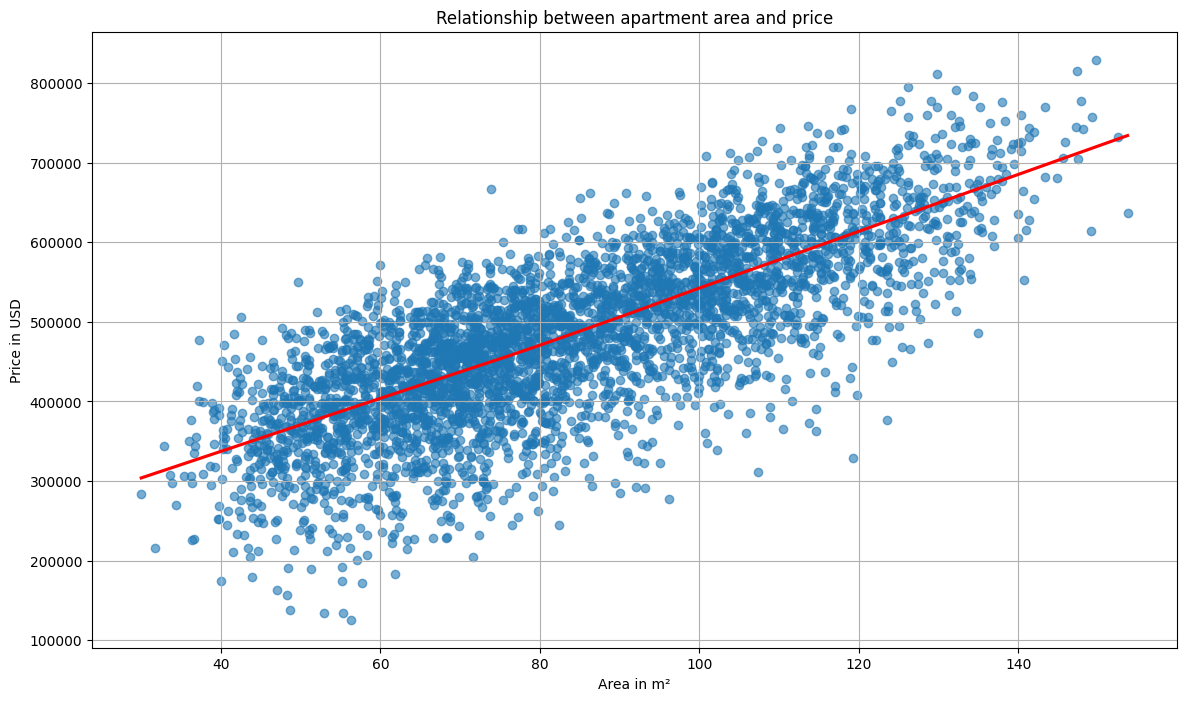

In [19]:
plt.figure(figsize=(14, 8))

sns.regplot(
    x=X_train["area_m2"],
    y=y_train,
    lowess=True,
    scatter_kws={"alpha": 0.6},
    line_kws={"color": "red"}
)

plt.title("Relationship between apartment area and price")
plt.xlabel("Area in m²")
plt.ylabel("Price in USD")
plt.grid()
plt.show()

there is a clear positive relationship (area increases togetger with price)

In [20]:
X_train['area_m2'].corr(y_train)

np.float64(0.7686961836533612)

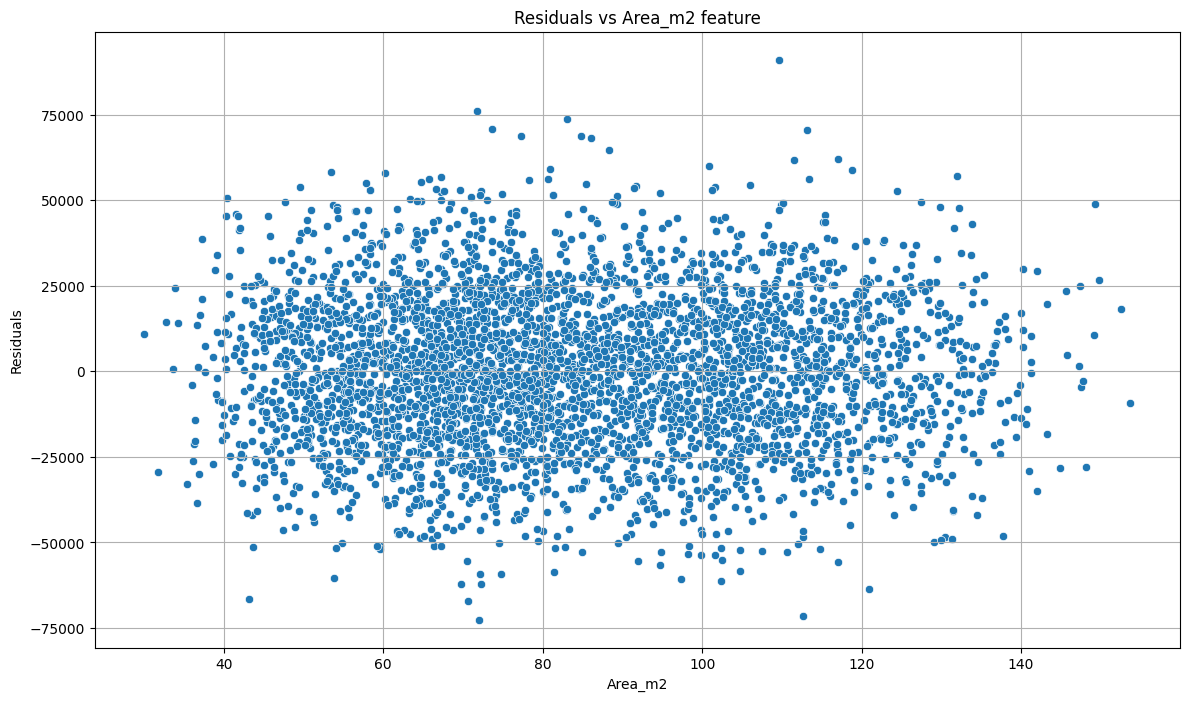

In [21]:
plt.figure(figsize=(14, 8))
sns.scatterplot(
    x=X_train['area_m2'],
    y=residuals
)
plt.title("Residuals vs Area_m2 feature")
plt.xlabel("Area_m2")
plt.ylabel("Residuals")
plt.grid()
plt.show()

The residuals appear randomly scattered around zero without a clear curve. Therefore, there is no strong evidence that area_m2 violates the linearity assumption.

### **building_age_years** feature vs **apartment_price_in_usd** target linearity

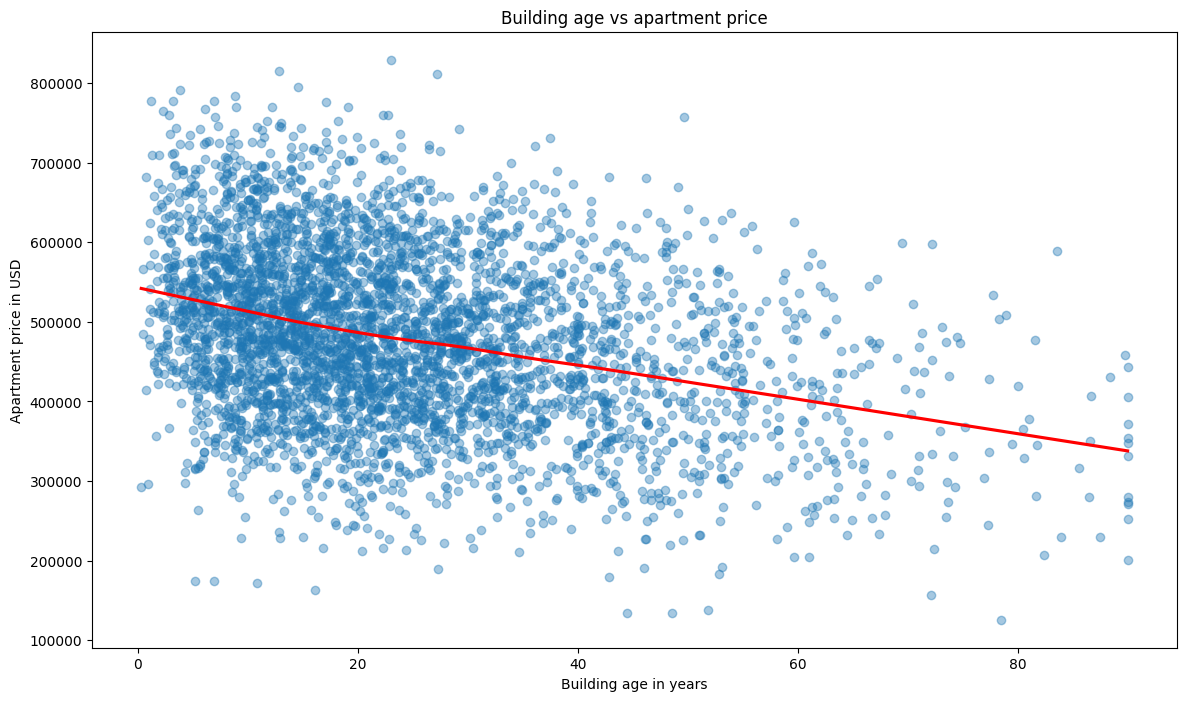

In [22]:
plt.figure(figsize=(14, 8))

sns.regplot(
    x=X_train["building_age_years"],
    y=y_train,
    lowess=True,
    scatter_kws={"alpha": 0.4},
    line_kws={"color": "red"}
)

plt.title("Building age vs apartment price")
plt.xlabel("Building age in years")
plt.ylabel("Apartment price in USD")
plt.show()

building_age_years has an approximately linear, negative, but relatively weak relationship with apartment price.

In [23]:
X_train["building_age_years"].corr(y_train)

np.float64(-0.32437321160675964)

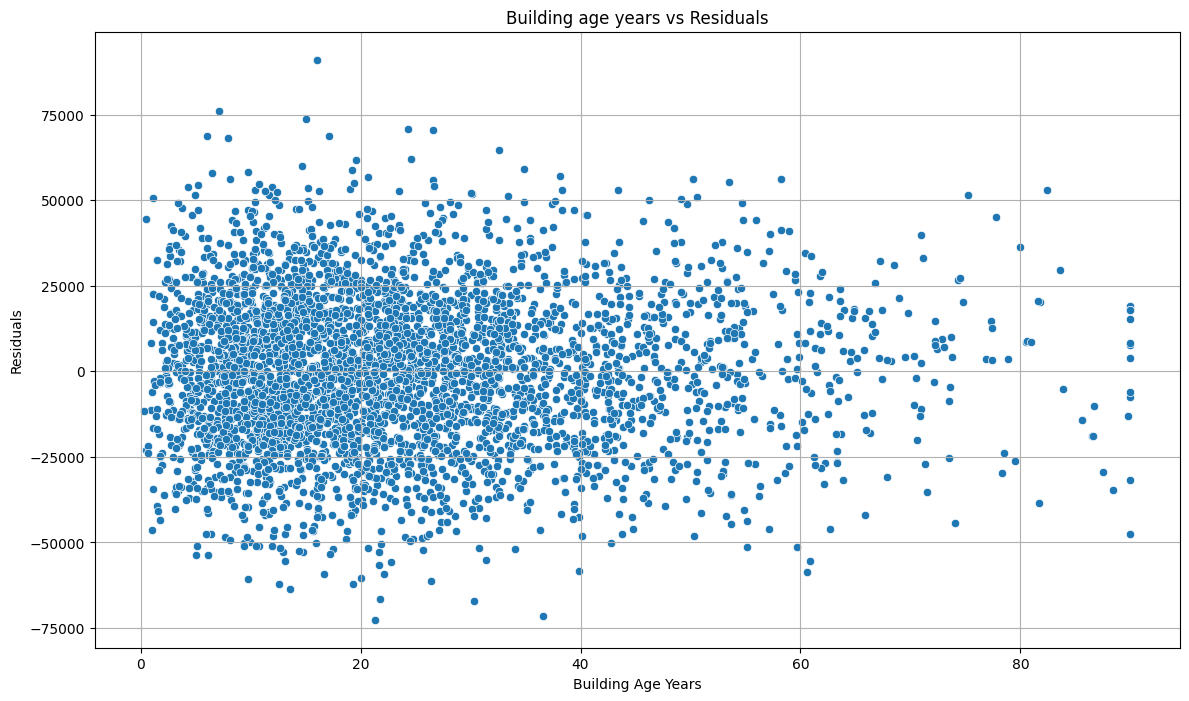

In [24]:
plt.figure(figsize=(14, 8))
sns.scatterplot(
    x=X_train['building_age_years'],
    y=residuals
)
plt.title("Building age years vs Residuals")
plt.xlabel("Building Age Years")
plt.ylabel("Residuals")
plt.grid()
plt.show()

## Independence of errors

#### Residuals vs observation order

In [25]:
# since we shufflied train_data , we have to order at first
diagnostic_df = pd.DataFrame({
    "original_order":X_train.index,
    "residuals":residuals
})
diagnostic_df = diagnostic_df.sort_values(by='original_order')
diagnostic_df.head()

,original_order,residuals
0,0,-32829.299472
1,1,7691.810098
2,2,5191.805631
6,6,-14797.958238
7,7,18311.730980


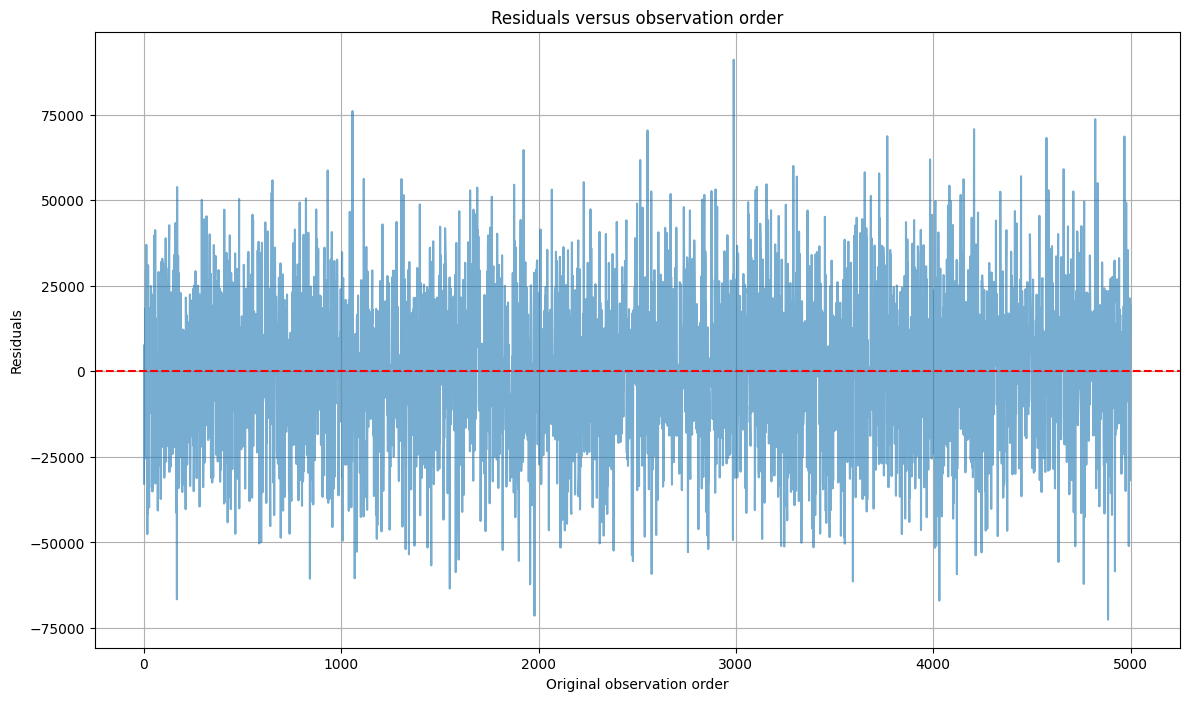

In [26]:
plt.figure(figsize=(14, 8))

plt.plot(
    diagnostic_df['original_order'],
    diagnostic_df['residuals'],
    alpha=0.6
)
plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.title("Residuals versus observation order")
plt.xlabel("Original observation order")
plt.ylabel("Residuals")
plt.grid()
plt.show()

no any evidence of dependent errors, residuals appear randomly distributed above and below zeor

#### Lag plot (comparing each residual with previos one)

In [27]:
ordered_residuals = diagnostic_df['residuals'].to_numpy()
previous_residuals = ordered_residuals[:-1]
current_residuals = ordered_residuals[1:]


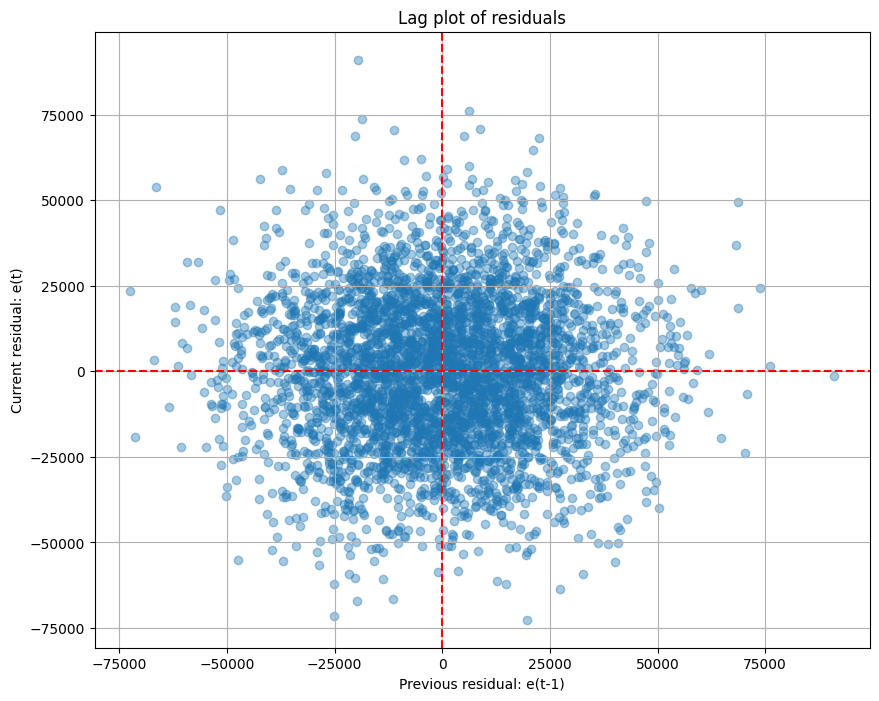

In [28]:
plt.figure(figsize=(10, 8))

plt.scatter(
    previous_residuals,
    current_residuals,
    alpha=0.4
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.axvline(
    x=0,
    color="red",
    linestyle="--"
)

plt.title("Lag plot of residuals")
plt.xlabel("Previous residual: e(t-1)")
plt.ylabel("Current residual: e(t)")
plt.grid()
plt.show()

The points from a random cloud without a clear direction, this means knowing the previous residuals doesn't help predict the current residual

## Homoscedasticity

#### Scatter plots

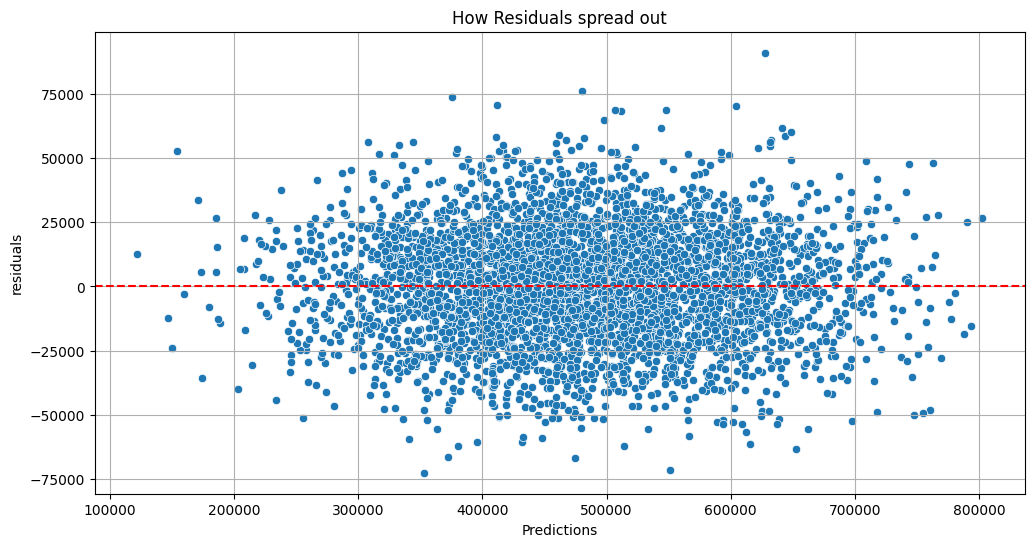

In [29]:
plt.figure(figsize=(12, 6))
sns.scatterplot(
    x=y_train_pred,
    y=residuals
)
plt.axhline(y=0, color='red', linestyle='--')
plt.title("How Residuals spread out")
plt.xlabel("Predictions")
plt.ylabel("residuals")
plt.grid()
plt.show()

THe residuals have a similar vertical spread across all predicted values, no funnel shape and no clear widening or narrowing pattern. it is Homoscedasticity, no evidence for heteroscedasticity 

#### Breush-Pagan test

In [30]:
from statsmodels.stats.diagnostic import het_breuschpagan

bp_result = het_breuschpagan(
    residuals,
    X_with_intercept
)

lm_statistic = bp_result[0]
lm_p_value = bp_result[1]
f_statistic = bp_result[2]
f_p_value = bp_result[3]

print("LM statistic:", lm_statistic)
print("LM p-value:", lm_p_value)
print("F statistic:", f_statistic)
print("F p-value:", f_p_value)

LM statistic: 12.464518249003298
LM p-value: 0.8648218167955316
F statistic: 0.6547875427008213
F p-value: 0.8655904110302418


LM p-value > 0.05, this means there is no evidence for heteroscedasticity

## Normality of errors

#### Histogram

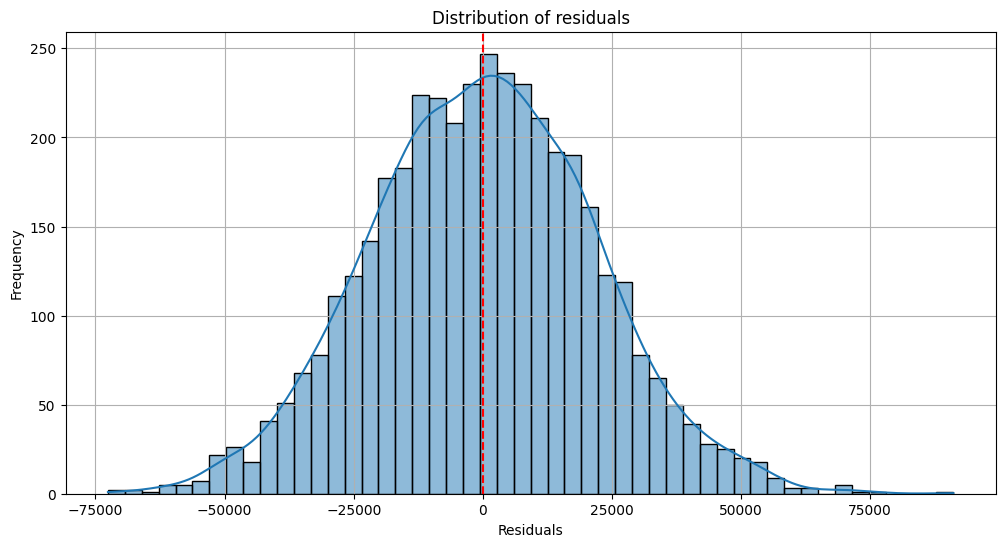

In [31]:
plt.figure(figsize=(12, 6))
sns.histplot(
    residuals,
    bins=50,
    kde=True
)
plt.axvline(
    x=0,
    color='red',
    linestyle='--',
    label='zero'
)
plt.title("Distribution of residuals")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.grid()
plt.show()

One centeral peak approximately at zero, roughly symmetic lef and right sides, frequencies gradually decreasing toward both tails, they all give evidences for normality of errors

#### Q-Q plot

<Figure size 1200x600 with 0 Axes>

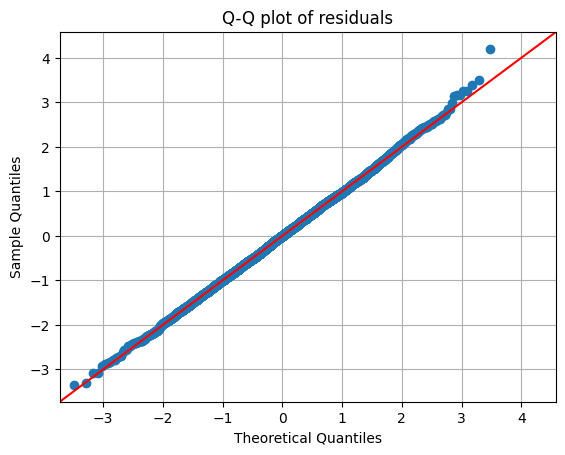

In [32]:
import statsmodels.api as sm

plt.figure(figsize=(12, 6))
sm.qqplot(
    residuals,
    line='45',
    fit=True
)
plt.title('Q-Q plot of residuals')
plt.grid()
plt.show()

Most blue points lie very close to the red reference line, especially in the centre and most of both tails.

This means the residual quantiles closely match the quantiles expected from a normal distribution.

There is only a small deviation in the far upper-right tail, including one point around:

sample quantile≈4.2

This suggests one or a few unusually large positive residuals. However, the deviation is not large enough to show a serious normality problem.

#### Skewness and Kurtosis

In [33]:
residuals.skew()

np.float64(0.04828630458044613)

skewness value 0.05 shows that residuals is approximately symmetic or normal distributed

In [34]:
residuals.kurt()

np.float64(0.04364686556010877)

kurtosis value is 0.04, it shows that residuals has Mesokurtic similar to normal distribution

## Absence of Multicollinearity

#### Correlation Heatmap

In [35]:
X_train.head()

,area_m2,rooms,bedrooms,bathrooms,floor,total_floors,building_age_years,distance_city_center_km,distance_public_transport_km,school_rating,crime_index,parks_within_1km,parking_spaces,renovation_score,energy_efficiency_score,noise_level,neighborhood_income_index,has_elevator,is_new_building
1501,75.7,3,2,1,3,8,37.5,5.35,0.61,7.2,25.8,4,0,6.7,5.9,52.2,63.8,1,0
2586,53.6,2,1,1,5,18,24.8,3.04,1.22,8.3,20.2,1,1,4.7,7.2,48.0,79.1,0,0
2653,60.8,3,1,2,9,15,17.5,6.06,0.05,8.9,20.2,2,1,7.6,7.8,48.3,71.8,0,0
1055,79.1,4,2,1,12,17,79.5,2.84,0.20,9.3,16.2,2,1,2.4,4.3,42.7,58.3,1,0
705,131.4,6,5,2,5,11,16.1,11.82,0.69,6.6,34.9,4,0,8.6,7.9,43.4,56.3,1,0


In [36]:
correlation_matrix = X_train.corr()
correlation_matrix

,area_m2,rooms,bedrooms,bathrooms,floor,total_floors,building_age_years,distance_city_center_km,distance_public_transport_km,school_rating,crime_index,parks_within_1km,parking_spaces,renovation_score,energy_efficiency_score,noise_level,neighborhood_income_index,has_elevator,is_new_building
area_m2,1.000000,0.869025,0.929424,0.591219,0.007483,0.008668,-0.008664,0.024163,-0.011898,0.025247,0.006375,0.012665,0.010850,0.015411,0.005269,-0.014985,-0.017627,-0.002610,-0.002605
rooms,0.869025,1.000000,0.934357,0.457768,0.006629,0.008979,0.002468,0.030198,-0.010135,0.024940,0.014159,0.018702,-0.006519,0.013694,0.001387,-0.016307,-0.024161,0.002417,-0.006700
bedrooms,0.929424,0.934357,1.000000,0.491147,0.013687,0.012109,-0.004259,0.020748,-0.000616,0.024800,0.003290,0.009306,0.004277,0.014590,0.005180,-0.009812,-0.019687,0.004993,-0.006084
bathrooms,0.591219,0.457768,0.491147,1.000000,0.005154,-0.003999,0.013055,0.019220,-0.011095,0.015095,0.006290,0.009063,0.019302,-0.012677,-0.010170,-0.004231,-0.022824,-0.008636,0.005852
floor,0.007483,0.006629,0.013687,0.005154,1.000000,0.589932,-0.015072,-0.036715,0.013726,-0.004588,-0.029967,0.039005,0.007665,0.009791,0.004379,0.294723,0.031805,0.130928,0.016804
total_floors,0.008668,0.008979,0.012109,-0.003999,0.589932,1.000000,-0.004078,-0.027823,0.006293,-0.022729,-0.025621,0.033181,-0.021480,-0.006660,-0.000286,0.196350,0.012656,0.209754,0.008451
building_age_years,-0.008664,0.002468,-0.004259,0.013055,-0.015072,-0.004078,1.000000,0.012451,0.030697,0.014202,-0.010277,0.005704,-0.000111,-0.595101,-0.695148,-0.006191,0.011474,0.014760,-0.307985
distance_city_center_km,0.024163,0.030198,0.020748,0.019220,-0.036715,-0.027823,0.012451,1.000000,0.000393,-0.425217,0.660286,-0.257175,0.005859,0.007396,-0.015657,-0.532353,-0.626004,-0.003972,0.000296
distance_public_transport_km,-0.011898,-0.010135,-0.000616,-0.011095,0.013726,0.006293,0.030697,0.000393,1.000000,0.013813,-0.001517,-0.029353,0.008563,-0.007032,-0.007768,0.022244,0.013874,0.001952,0.000864
school_rating,0.025247,0.024940,0.024800,0.015095,-0.004588,-0.022729,0.014202,-0.425217,0.013813,1.000000,-0.451673,0.112183,-0.006043,-0.020034,-0.004920,0.205546,0.473330,-0.011065,-0.009961


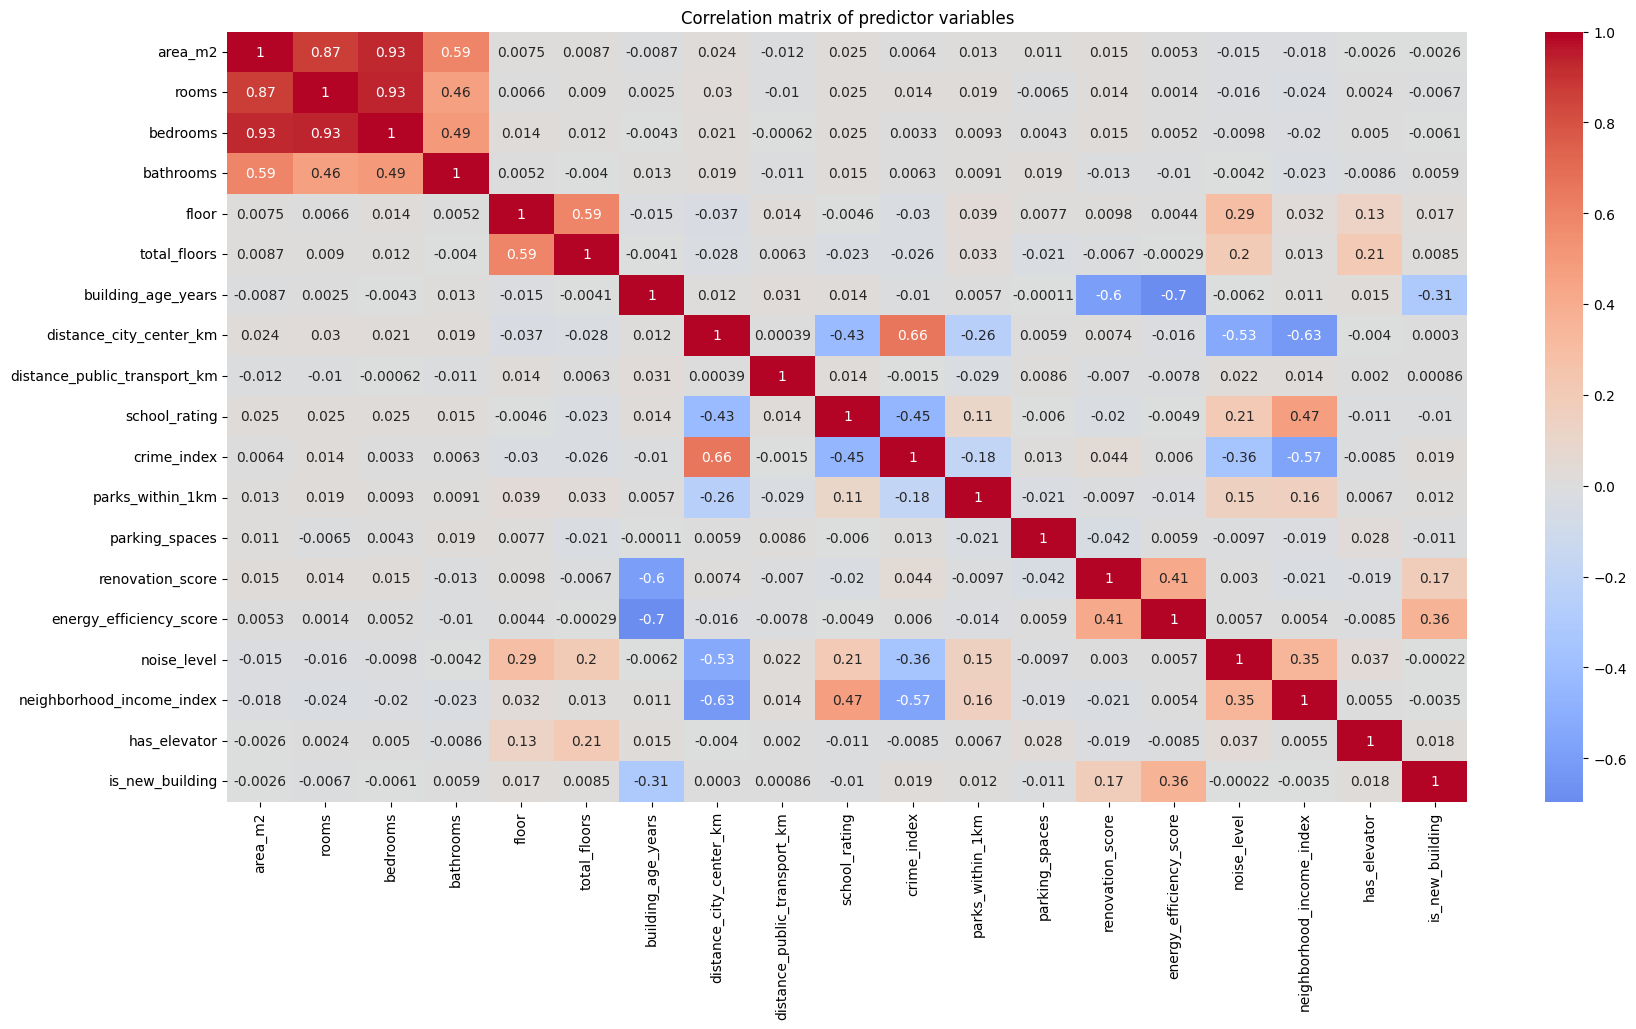

In [37]:
plt.figure(figsize=(20, 10))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    center=0
)
plt.title("Correlation matrix of predictor variables")
plt.show()

In [38]:
from itertools import combinations

correlation_records = []
for col1, col2 in combinations(correlation_matrix.columns, 2):
    correlation_records.append({
        "column1":col1,
        "column2":col2,
        "correlation":correlation_matrix.loc[col1, col2]
    })
correlation_df = pd.DataFrame(correlation_records)
correlation_df[correlation_df['correlation'] > 0.70]

,column1,column2,correlation
0,area_m2,rooms,0.869025
1,area_m2,bedrooms,0.929424
18,rooms,bedrooms,0.934357


The correlation analysis identified strong pairwise relationships among area_m2, rooms, and bedrooms. Therefore, these features may cause multicollinearity, and VIF should be calculated to evaluate its severity.

# Common techniques

## VIF (Variance Inflation Factor)

In [39]:
X_train.head()

,area_m2,rooms,bedrooms,bathrooms,floor,total_floors,building_age_years,distance_city_center_km,distance_public_transport_km,school_rating,crime_index,parks_within_1km,parking_spaces,renovation_score,energy_efficiency_score,noise_level,neighborhood_income_index,has_elevator,is_new_building
1501,75.7,3,2,1,3,8,37.5,5.35,0.61,7.2,25.8,4,0,6.7,5.9,52.2,63.8,1,0
2586,53.6,2,1,1,5,18,24.8,3.04,1.22,8.3,20.2,1,1,4.7,7.2,48.0,79.1,0,0
2653,60.8,3,1,2,9,15,17.5,6.06,0.05,8.9,20.2,2,1,7.6,7.8,48.3,71.8,0,0
1055,79.1,4,2,1,12,17,79.5,2.84,0.20,9.3,16.2,2,1,2.4,4.3,42.7,58.3,1,0
705,131.4,6,5,2,5,11,16.1,11.82,0.69,6.6,34.9,4,0,8.6,7.9,43.4,56.3,1,0


In [40]:
# Features 
X_auxiliary = X_train.drop(columns='rooms').to_numpy(dtype=float)
# Target
y_auxiliary = X_train['rooms'].to_numpy(dtype=float)

In [41]:
# 3. Add the intercept
ones = np.ones(
    (X_auxiliary.shape[0], 1)
)

X_auxiliary_with_intercept = np.hstack(
    (ones, X_auxiliary)
)

In [42]:
# Training OLS model
X_transpose = X_auxiliary_with_intercept.T

XTX = (
    X_transpose
    @ X_auxiliary_with_intercept
)

XTy = (
    X_transpose
    @ y_auxiliary
)

XTX_inverse = np.linalg.pinv(XTX)

beta_auxiliary = (
    XTX_inverse
    @ XTy
)

In [43]:
auxiliary_intercept = beta_auxiliary[0]
auxiliary_coefficients = beta_auxiliary[1:]

In [ ]:
# making predictions
y_auxiliary_pred = (
    X_auxiliary_with_intercept
    @ beta_auxiliary
)

In [45]:
# residuals calculation
auxiliary_residuals = (
    y_auxiliary
    - y_auxiliary_pred
)

In [46]:
# calculating SSE
SSE = np.sum(
    auxiliary_residuals ** 2
)

In [47]:
# Calculating SST 
rooms_mean = np.mean(y_auxiliary)

SST = np.sum(
    (y_auxiliary - rooms_mean) ** 2
)

In [48]:
# Calculate Auxiliary R² 
R_squared_rooms = 1 - (SSE / SST)
R_squared_rooms

np.float64(0.8737166137842157)

In [49]:
# calculate Tolerance 
tolerance_rooms = 1 - R_squared_rooms
tolerance_rooms

np.float64(0.12628338621578428)

In [50]:
VIF_rooms = 1 / tolerance_rooms
VIF_rooms

np.float64(7.9186980169447585)

In [51]:
print(f"R sqaured rooms {R_squared_rooms}")
print(f"Tolerace rooms {tolerance_rooms}")
print(f"VIF rooms {VIF_rooms}")

R sqaured rooms 0.8737166137842157
Tolerace rooms 0.12628338621578428
VIF rooms 7.9186980169447585


Approximately 87% of the variation in rooms can be explauned by the all the other predictor variables tother or 12.63% of the variation in rooms is unique and cannot be explained by the other predictors. The `rooms` feature has moderately high or potenially problematic multicollineariy. 

## Cook's Distance

In [52]:
price_predictions = X_with_intercept @ beta_hat

price_residuals = y_vector - price_predictions

In [53]:
n_price = X_with_intercept.shape[0]
p_price = X_with_intercept.shape[1]

sse_price = np.sum(price_residuals ** 2)

mse_price = sse_price / (n_price - p_price)

print("Price-model SSE:", sse_price)
print("Price-model MSE:", mse_price)

Price-model SSE: 1882050257978.62
Price-model MSE: 472876949.2408593


In [54]:
xtx_price = (
    X_with_intercept.T
    @ X_with_intercept
)

xtx_inverse_price = np.linalg.pinv(
    xtx_price
)

In [55]:
price_leverages = np.sum(
    (
        X_with_intercept
        @ xtx_inverse_price
    )
    * X_with_intercept,
    axis=1
)

In [56]:
print("Mean leverage:", price_leverages.mean())
print("Expected mean leverage:", p_price / n_price)

print("Sum of leverage:", price_leverages.sum())
print("Expected sum:", p_price)

Mean leverage: 0.004999999999999176
Expected mean leverage: 0.005
Sum of leverage: 19.999999999996703
Expected sum: 20


In [57]:
cooks_distance_price = (
    price_residuals ** 2
    / (p_price * mse_price)
) * (
    price_leverages
    / (1 - price_leverages) ** 2
)

In [58]:
cooks_df = pd.DataFrame({
    "original_index": X_train.index,
    "actual_price": y_vector,
    "predicted_price": price_predictions,
    "residual": price_residuals,
    "leverage": price_leverages,
    "cooks_distance": cooks_distance_price
})

In [59]:
cooks_df.sort_values(
    by="cooks_distance",
    ascending=False
).head(10)

,original_index,actual_price,predicted_price,residual,leverage,cooks_distance
1677,2989,719141.57,628045.191981,91096.378019,0.004278,0.003786
35,2515,703374.33,641594.896318,61779.433682,0.008596,0.003529
1405,4215,555153.94,608929.403960,-53775.463960,0.011238,0.003515
1599,4886,280524.27,353112.702193,-72588.432193,0.005710,0.003218
1996,3100,207096.19,154130.993016,52965.196984,0.010081,0.003051
1303,4821,448871.01,375146.926045,73724.083955,0.005053,0.002933
1623,1114,400019.48,343747.169376,56272.310624,0.008458,0.002881
385,1550,589273.04,652750.669187,-63477.629187,0.006568,0.002835
1198,3593,553895.11,615295.940733,-61400.830733,0.006657,0.002689
2986,3402,594229.36,636276.194912,-42046.834912,0.013792,0.002651


In [60]:
treshold = 4 / n_price
treshold

0.001

In [61]:
low_cooks_dis_df = cooks_df[cooks_df['cooks_distance']  < treshold]
high_cooks_dis_df = cooks_df[cooks_df['cooks_distance']  > treshold]

print(f"Number observations with high influence {len(high_cooks_dis_df)}")
print(f"Number observations with low influence {len(low_cooks_dis_df)}")

Number observations with high influence 211
Number observations with low influence 3789


In [62]:
high_indices = high_cooks_dis_df[
    "original_index"
]

high_influence_features = X_train.loc[
    high_indices
].copy()

high_influence_features.head(20)

,area_m2,rooms,bedrooms,bathrooms,floor,total_floors,building_age_years,distance_city_center_km,distance_public_transport_km,school_rating,crime_index,parks_within_1km,parking_spaces,renovation_score,energy_efficiency_score,noise_level,neighborhood_income_index,has_elevator,is_new_building
4767,55.7,2,1,2,3,4,44.7,0.61,0.26,8.0,18.7,2,1,4.9,5.4,35.7,82.1,0,0
4842,67.4,4,2,1,5,22,1.5,14.02,0.19,6.8,31.4,3,1,10.0,10.0,35.7,79.8,1,1
2515,111.5,6,4,2,24,24,19.6,1.89,0.66,7.6,22.5,5,0,4.7,5.0,46.8,87.0,0,0
3599,104.4,4,3,3,3,26,4.0,2.11,0.66,7.4,22.7,4,0,8.4,9.1,40.6,72.1,0,1
4635,117.0,6,5,1,5,19,22.8,1.33,0.18,8.2,22.0,4,0,8.0,6.8,42.5,78.4,1,0
168,49.6,2,1,1,7,11,4.3,0.79,1.20,8.9,25.9,2,1,7.1,9.8,47.7,85.1,1,1
3862,75.9,3,2,2,12,14,16.2,4.89,1.35,6.1,23.2,4,0,6.3,9.6,47.9,58.5,1,0
2527,132.2,7,5,1,5,13,3.8,2.59,0.58,8.8,27.3,0,0,8.4,9.9,44.7,80.6,1,1
931,118.8,5,4,2,2,6,19.2,4.85,0.08,10.0,26.0,0,0,9.1,6.8,36.7,73.9,1,0
1057,71.8,4,2,1,1,7,7.1,4.10,0.06,8.5,16.1,2,1,6.8,8.4,42.0,59.8,1,0


In [63]:
high_cooks_dis_df.sort_values(
    by='cooks_distance',
    ascending=False
).head(10)

,original_index,actual_price,predicted_price,residual,leverage,cooks_distance
1677,2989,719141.57,628045.191981,91096.378019,0.004278,0.003786
35,2515,703374.33,641594.896318,61779.433682,0.008596,0.003529
1405,4215,555153.94,608929.403960,-53775.463960,0.011238,0.003515
1599,4886,280524.27,353112.702193,-72588.432193,0.005710,0.003218
1996,3100,207096.19,154130.993016,52965.196984,0.010081,0.003051
1303,4821,448871.01,375146.926045,73724.083955,0.005053,0.002933
1623,1114,400019.48,343747.169376,56272.310624,0.008458,0.002881
385,1550,589273.04,652750.669187,-63477.629187,0.006568,0.002835
1198,3593,553895.11,615295.940733,-61400.830733,0.006657,0.002689
2986,3402,594229.36,636276.194912,-42046.834912,0.013792,0.002651
